# Effort Index Calculation

This notebook calculates a student 'Effort Index' based on three datasets:
1. `question_metadata.csv`
2. `question_differentiation_cummulative.csv`
3. `processed_responses.csv`

The Effort Index helps identify students who are not giving appropriate effort to easy questions that generally have a low worsening rate.

## Step 1: Data Loading & Preprocessing
Load the three CSV files using pandas and calculate the `Error_Score` in the responses dataframe using the formula: `1 - Response`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Data Loading & Preprocessing
# Assume the files are in the same directory as the notebook
df_meta = pd.read_csv('question_metadata.csv')
df_diff = pd.read_csv('question_differentiation_cummulative.csv')
df_resp = pd.read_csv('processed_responses.csv')

# Calculate Error_Score: 1 - Response
df_resp['Error_Score'] = 1 - df_resp['Response']
df_resp.head()

,Student_ID,Question_ID,Response,Error_Score
0,1001,58,1,0
1,1001,74,0,1
2,1001,27,1,0
3,1001,82,1,0
4,1001,37,1,0


## Step 2: Identify Target "Easy" Questions
- Filter `question_metadata` for `Level == 1`.
- Filter `question_differentiation_cummulative` for questions in the lower quartile (25th percentile) of `Worsening_Rate`.
- Find the intersection of these two filtered sets to create a list of `Target_Easy_Questions`. Map these back to their respective `LO`s.

In [2]:
# Step 2: Identify Target "Easy" Questions
# Filter metadata for Level 1 (Easy) questions
easy_meta = df_meta[df_meta['Level'] == 1]

# Filter differentiation for lower quartile of Worsening_Rate
worsening_threshold = df_diff['Worsening_Rate'].quantile(0.25)
low_worsening_diff = df_diff[df_diff['Worsening_Rate'] <= worsening_threshold]

# Find intersection to get Target Easy Questions
target_easy_questions = pd.merge(easy_meta, low_worsening_diff, on='Question_ID', how='inner')

print(f"Number of Target Easy Questions: {len(target_easy_questions)}")
target_easy_questions[['Question_ID', 'LO', 'Level', 'Worsening_Rate']].head()

Number of Target Easy Questions: 12


,Question_ID,LO,Level,Worsening_Rate
0,7,LO3,1,0.086564
1,15,LO6,1,0.178693
2,17,LO2,1,0.089120
3,19,LO6,1,0.140098
4,40,LO4,1,0.060647


## Step 3: Calculate LO-Level Error Rates
- Merge the `LO` mapping onto the responses dataframe.
- Group the responses by `Student_ID` and `LO`, calculating the mean `Error_Score`. Name this `LO_Error_Rate`.

In [3]:
# Step 3: Calculate LO-Level Error Rates
# Get the mapping of Question_IDs to their LOs from metadata
q_lo_mapping = df_meta[['Question_ID', 'LO']]

# Merge LO mapping onto responses
resp_with_lo = pd.merge(df_resp, q_lo_mapping, on='Question_ID', how='left')

# Group by Student_ID and LO to get the mean Error_Score (LO_Error_Rate)
lo_error_rates = resp_with_lo.groupby(['Student_ID', 'LO'])['Error_Score'].mean().reset_index()
lo_error_rates.rename(columns={'Error_Score': 'LO_Error_Rate'}, inplace=True)

lo_error_rates.head()

,Student_ID,LO,LO_Error_Rate
0,1001,LO1,0.500000
1,1001,LO10,0.375000
2,1001,LO2,0.428571
3,1001,LO3,0.400000
4,1001,LO4,0.500000


## Step 4: Calculate the Effort Index
- Filter the responses dataframe to only include the `Target_Easy_Questions`.
- Merge the `LO_Error_Rate` back onto this filtered dataframe based on `Student_ID` and `LO`.
- Calculate the `Delta` for each row using the formula: `LO_Error_Rate - Error_Score`.
- Group by `Student_ID` and calculate the mean of the `Delta` column. This is the `Effort_Index`.

In [4]:
# Step 4: Calculate the Effort Index
# Filter responses for Target Easy Questions
target_q_ids = target_easy_questions['Question_ID'].tolist()
easy_responses = resp_with_lo[resp_with_lo['Question_ID'].isin(target_q_ids)]

# Merge LO_Error_Rate back onto filtered dataframe based on Student_ID and LO
easy_responses_with_lo_rate = pd.merge(easy_responses, lo_error_rates, on=['Student_ID', 'LO'], how='left')

# Calculate Delta: LO_Error_Rate - Error_Score
easy_responses_with_lo_rate['Delta'] = easy_responses_with_lo_rate['LO_Error_Rate'] - easy_responses_with_lo_rate['Error_Score']

# Calculate Effort Index by taking the mean of Delta per student
effort_index_df = easy_responses_with_lo_rate.groupby('Student_ID')['Delta'].mean().reset_index()
effort_index_df.rename(columns={'Delta': 'Effort_Index'}, inplace=True)

effort_index_df.head()

,Student_ID,Effort_Index
0,1001,0.135714
1,1002,-0.125000
2,1003,0.159259
3,1004,0.141667
4,1005,0.028869


## Step 5: Statistical Analysis & Thresholding
- Calculate and print the sample statistics for the `Effort_Index` (Mean, Median, Standard Deviation).
- Plot a histogram of the `Effort_Index` distribution using seaborn or matplotlib. Include a vertical line denoting the mean.
- Define a threshold to flag low-effort students. Calculate the threshold as: `Mean - (1 * Standard_Deviation)`.
- Create a final dataframe of 'Flagged Students' whose `Effort_Index` is below this threshold and display the head of this dataframe.

--- Effort Index Statistics ---
Mean:   0.0666
Median: 0.0622
StdDev: 0.1617


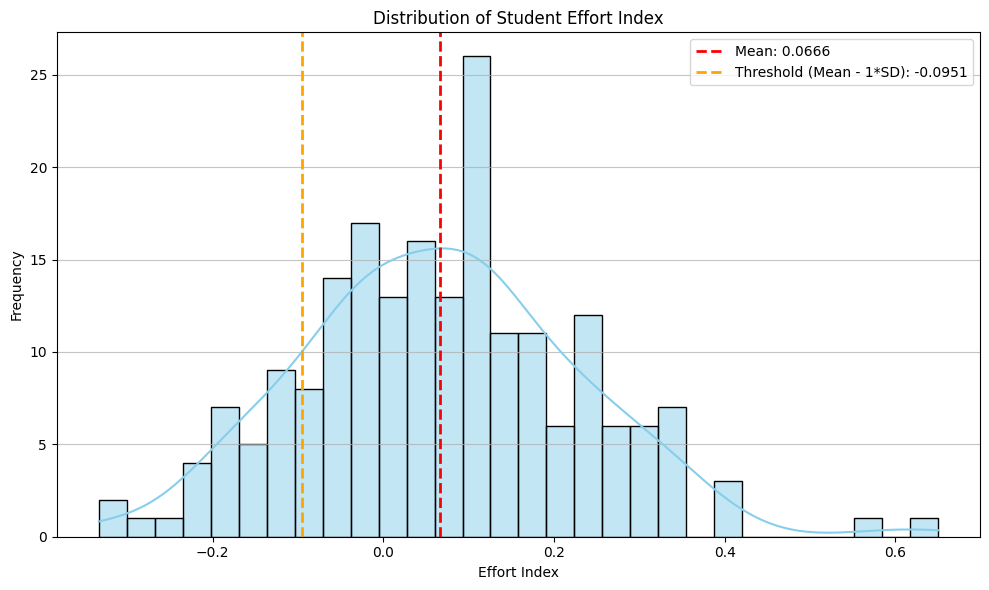


Threshold for flagging low-effort students: -0.0951
Number of flagged students: 34

Flagged Students Dataframe Head:


,Student_ID,Effort_Index
1,1002,-0.125000
6,1007,-0.203061
10,1011,-0.104762
11,1012,-0.216667
28,1029,-0.176587


In [5]:
# Step 5: Statistical Analysis & Thresholding
# Sample Statistics for Effort Index
mean_ei = effort_index_df['Effort_Index'].mean()
median_ei = effort_index_df['Effort_Index'].median()
std_ei = effort_index_df['Effort_Index'].std()

print("--- Effort Index Statistics ---")
print(f"Mean:   {mean_ei:.4f}")
print(f"Median: {median_ei:.4f}")
print(f"StdDev: {std_ei:.4f}")

# Plot Histogram of Effort Index distribution
plt.figure(figsize=(10, 6))
sns.histplot(effort_index_df['Effort_Index'], bins=30, kde=True, color='skyblue')
plt.axvline(mean_ei, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_ei:.4f}')
plt.axvline(mean_ei - std_ei, color='orange', linestyle='dashed', linewidth=2, label=f'Threshold (Mean - 1*SD): {mean_ei - std_ei:.4f}')
plt.title('Distribution of Student Effort Index')
plt.xlabel('Effort Index')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

# Define Threshold and Flag Students
# Threshold: Mean - (1 * Standard Deviation)
threshold = mean_ei - std_ei
flagged_students = effort_index_df[effort_index_df['Effort_Index'] < threshold].copy()

print(f"\nThreshold for flagging low-effort students: {threshold:.4f}")
print(f"Number of flagged students: {len(flagged_students)}")
print("\nFlagged Students Dataframe Head:")
flagged_students.head()